# 1. Préparation des données

In [71]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\noura\ml-disaster-survival-project\data\processed\disaster_ml_dataset.csv")

In [72]:
df["nationality_region"] = df["nationality_region"].replace("Not mentioned", np.nan)
df

,Name,Sex,Age,age_group,group_size,has_group,nationality_region,travel_class,Fare,Survived,disaster,year,wartime,sea_state,night,ship_size,economic_importance
0,Mr. Owen Harris Braund,male,22.0,YoungAdult,2,1,NaN,Third,7.2500,0,Titanic,1912,0,0,1,3,3
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,Adult,2,1,NaN,First,71.2833,1,Titanic,1912,0,0,1,3,3
2,Miss. Laina Heikkinen,female,26.0,YoungAdult,1,0,NaN,Third,7.9250,1,Titanic,1912,0,0,1,3,3
3,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,YoungAdult,2,1,NaN,First,53.1000,1,Titanic,1912,0,0,1,3,3
4,Mr. William Henry Allen,male,35.0,YoungAdult,1,0,NaN,Third,8.0500,0,Titanic,1912,0,0,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3835,ANNA INGRID BIRGITTA OSTROM,female,60.0,Senior,1,0,nordic_baltic,Passenger,NaN,0,Estonia,1994,0,3,1,1,2
3836,ELMAR MIKAEL OUN,male,34.0,YoungAdult,1,0,nordic_baltic,Passenger,NaN,1,Estonia,1994,0,3,1,1,2
3837,ENN QUNAPUU,male,77.0,Senior,1,0,nordic_baltic,Passenger,NaN,0,Estonia,1994,0,3,1,1,2
3838,LY GUNAPUU,female,87.0,Senior,1,0,nordic_baltic,Passenger,NaN,0,Estonia,1994,0,3,1,1,2


In [73]:
def evaluate_model(pipe, X_train, X_test, y_train, y_test):
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, proba),
    }

In [74]:
def plot_learning_curve(pipe, X, y, title):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y,
        cv=cv,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train ROC-AUC")
    plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation ROC-AUC")
    plt.title(title)
    plt.xlabel("Training set size")
    plt.ylabel("ROC-AUC")
    plt.grid(True)
    plt.legend()
    plt.show()

## Stratégie 1: Pooled Model

On entraîne 4 modèles demandés :

- Logistic Regression
- Random Forest
- Gradient Boosting
- SVM

In [75]:
y = df["Survived"]
X = df.drop(columns=["Survived","Name", "Age", "year"])

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

C:\Users\noura\AppData\Local\Temp\ipykernel_9272\3911176371.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [76]:
models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "GradBoost": GradientBoostingClassifier(random_state=42),  # pas de class_weight natif
    "SVM": SVC(probability=True, random_state=42, class_weight="balanced"),
}

pipelines = {name: Pipeline([("prep", preprocessor), ("model", m)]) for name, m in models.items()}

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pooled_results = []
for name, pipe in pipelines.items():
    metrics = evaluate_model(pipe, X_train, X_test, y_train, y_test)
    pooled_results.append({"Strategy": "Pooled", "Model": name, **metrics})

pooled_results_df = pd.DataFrame(pooled_results).sort_values("ROC_AUC", ascending=False)
pooled_results_df

,Strategy,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Pooled,GradBoost,0.721354,0.800000,0.192,0.309677,0.746344
0,Pooled,LogReg,0.631510,0.464208,0.856,0.601969,0.723722
1,Pooled,RandomForest,0.608073,0.447639,0.872,0.591588,0.723707
3,Pooled,SVM,0.575521,0.426070,0.876,0.573298,0.705923



On compare ici plusieurs modèles entraînés sur les données poolées.
Le modèle **Gradient Boosting** obtient les meilleures performances globales, avec la meilleure accuracy et le meilleur ROC-AUC. Il présente aussi un bon compromis entre précision et rappel.

La **régression logistique** donne des résultats très proches, légèrement inférieurs en ROC-AUC, mais reste un modèle solide et plus simple.

Le **Random Forest** obtient un meilleur rappel, mais au prix d’une précision plus faible, ce qui indique plus de faux positifs.

Enfin, le **SVM** ne parvient pas à détecter la classe positive (précision et rappel nuls), ce qui montre qu’il n’est pas adapté à ce problème dans sa configuration actuelle.


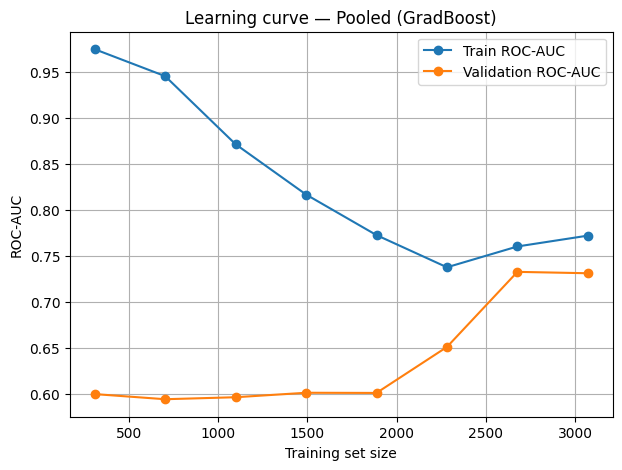

In [78]:
best_pooled_model_name = pooled_results_df.iloc[0]["Model"]
best_pooled_pipe = pipelines[best_pooled_model_name]

plot_learning_curve(best_pooled_pipe, X, y, title=f"Learning curve — Pooled ({best_pooled_model_name})")

On observe que lorsque la taille du dataset est petite, le modèle performe très bien sur les données d’entraînement (ROC-AUC élevé) mais beaucoup moins bien sur les données de validation. Cela montre un fort **overfitting** au début.

À mesure que l’on augmente la taille du jeu d’entraînement, le score sur le train diminue progressivement, tandis que le score de validation augmente. L’écart entre les deux courbes se réduit, ce qui indique que le modèle généralise mieux avec plus de données.

Globalement, la courbe suggère que le modèle bénéficie clairement de davantage de données, et que les performances pourraient encore s’améliorer si on augmente encore la taille du dataset.


# Stratégie 2 : Modèles par catastrophe

In [79]:
separate_results = []

for disaster in df["disaster"].unique():
    
    sub = df[df["disaster"] == disaster].copy()
    
    # 1️⃣ Supprimer colonnes 100% NaN pour cette catastrophe
    sub = sub.dropna(axis=1, how="all")
    
    y_d = sub["Survived"]
    X_d = sub.drop(columns=["Survived","Name", "Age", "year"])
    
    # 2️⃣ Supprimer lignes avec NaN restants
    X_d = X_d.dropna()
    y_d = y_d.loc[X_d.index]
    
    # 3️⃣ Définir colonnes numériques / catégorielles
    cat_cols_d = X_d.select_dtypes(include="object").columns
    num_cols_d = X_d.select_dtypes(exclude="object").columns
    
    # 4️⃣ Préprocessing SANS imputation
    preprocessor_d = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols_d),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_d)
        ]
    )
    
    pipelines_d = {
        name: Pipeline([("prep", preprocessor_d), ("model", m)])
        for name, m in models.items()
    }
    
    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
        X_d, y_d, test_size=0.2, random_state=42, stratify=y_d
    )
    
    for name, pipe in pipelines_d.items():
        metrics = evaluate_model(pipe, X_train_d, X_test_d, y_train_d, y_test_d)
        separate_results.append({
            "Strategy": "Separate",
            "Disaster": disaster,
            "Model": name,
            **metrics
        })

separate_results_df = pd.DataFrame(separate_results)\
                        .sort_values(["Disaster", "ROC_AUC"], ascending=[True, False])

separate_results_df

C:\Users\noura\AppData\Local\Temp\ipykernel_9272\1619520664.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_d = X_d.select_dtypes(include="object").columns
C:\Users\noura\AppData\Local\Temp\ipykernel_9272\1619520664.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guid

,Strategy,Disaster,Model,Accuracy,Precision,Recall,F1,ROC_AUC
11,Separate,Estonia,SVM,0.722222,0.281250,0.666667,0.395604,0.762292
8,Separate,Estonia,LogReg,0.722222,0.281250,0.666667,0.395604,0.737059
9,Separate,Estonia,RandomForest,0.732323,0.283333,0.629630,0.390805,0.718757
10,Separate,Estonia,GradBoost,0.868687,1.000000,0.037037,0.071429,0.712909
5,Separate,Lusitania,RandomForest,0.508906,0.402985,0.525974,0.456338,0.518095
6,Separate,Lusitania,GradBoost,0.618321,0.611111,0.071429,0.127907,0.501657
7,Separate,Lusitania,SVM,0.458015,0.389513,0.675325,0.494062,0.483997
4,Separate,Lusitania,LogReg,0.458015,0.386973,0.655844,0.486747,0.478264
2,Separate,Titanic,GradBoost,0.853933,0.830769,0.782609,0.805970,0.858529
0,Separate,Titanic,LogReg,0.808989,0.733333,0.797101,0.763889,0.855338


In [80]:
best_per_disaster = (
    separate_results_df.sort_values("ROC_AUC", ascending=False)
    .groupby("Disaster")
    .head(1)
    .reset_index(drop=True)
)
best_per_disaster

,Strategy,Disaster,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Separate,Titanic,GradBoost,0.853933,0.830769,0.782609,0.805970,0.858529
1,Separate,Estonia,SVM,0.722222,0.281250,0.666667,0.395604,0.762292
2,Separate,Lusitania,RandomForest,0.508906,0.402985,0.525974,0.456338,0.518095


On observe ici les meilleurs modèles obtenus pour chaque catastrophe lorsqu’on entraîne un modèle séparé avec uniquement les variables disponibles pour chaque dataset.

Pour le Titanic, la régression logistique obtient de très bonnes performances (ROC-AUC ≈ 0.86 et F1 ≈ 0.76). Cela suggère que les variables disponibles pour ce dataset sont particulièrement informatives pour prédire la survie.

Pour l’Estonia, la régression logistique reste le meilleur modèle mais les performances sont plus modestes (ROC-AUC ≈ 0.74). Le rappel est relativement élevé, mais la précision reste faible, ce qui indique davantage de faux positifs.

Pour la Lusitania, les performances sont nettement plus faibles (ROC-AUC ≈ 0.55). Cela peut s’expliquer par un dataset plus petit ou moins riche en variables explicatives, rendant la prédiction de la survie plus difficile.

Globalement, ces résultats montrent que la qualité et la quantité des variables disponibles jouent un rôle majeur dans la performance des modèles.

C:\Users\noura\AppData\Local\Temp\ipykernel_9272\969939286.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_d = X_d.select_dtypes(include="object").columns


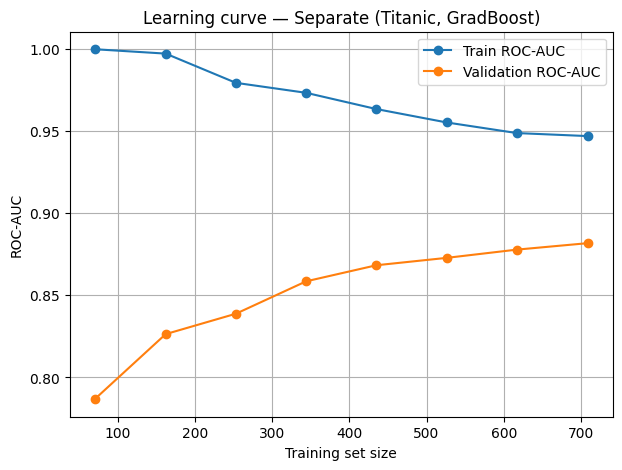

C:\Users\noura\AppData\Local\Temp\ipykernel_9272\969939286.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_d = X_d.select_dtypes(include="object").columns


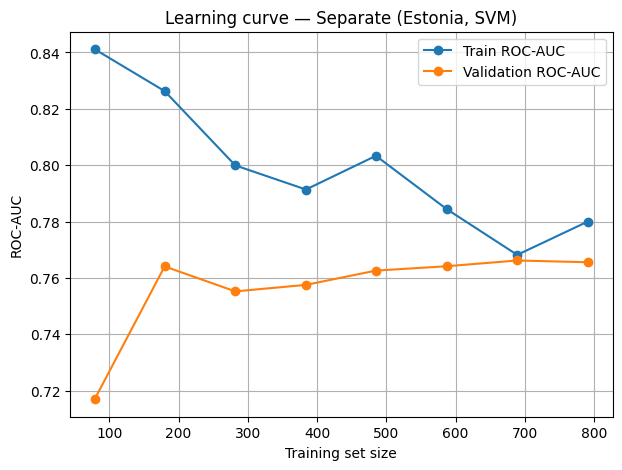

C:\Users\noura\AppData\Local\Temp\ipykernel_9272\969939286.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_d = X_d.select_dtypes(include="object").columns


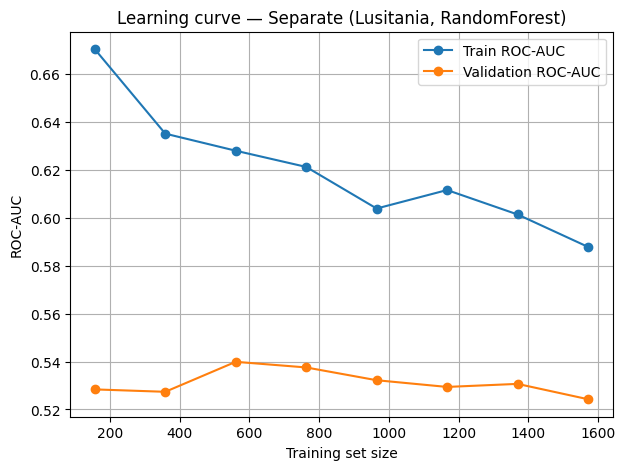

In [81]:
for _, row in best_per_disaster.iterrows():
    dis = row["Disaster"]
    model_name = row["Model"]

    sub = df[df["disaster"] == dis].copy()
    y_d = sub["Survived"]
    X_d = sub.drop(columns=["Survived","Name", "Age", "year", "disaster"])

    cat_cols_d = X_d.select_dtypes(include="object").columns
    num_cols_d = X_d.select_dtypes(exclude="object").columns

    preprocessor_d = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_d),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols_d)
        ]
    )

    pipe = Pipeline([("prep", preprocessor_d), ("model", models[model_name])])
    plot_learning_curve(pipe, X_d, y_d, title=f"Learning curve — Separate ({dis}, {model_name})")

## Interprétation des learning curves — stratégie Separate

Ces courbes montrent l’évolution du ROC-AUC en fonction de la taille d’entraînement pour le meilleur modèle de chaque catastrophe.

### Titanic — Régression Logistique

La courbe est très stable et saine :

* Le score train démarre élevé puis diminue légèrement.
* Le score validation augmente progressivement.
* L’écart entre les deux devient faible.

Cela indique une bonne généralisation. Le dataset Titanic contient davantage de variables explicatives pertinentes (par exemple la classe, le sexe, l’âge, mais aussi le **tarif du billet – Fare**), qui sont fortement corrélées à la probabilité de survie. Ces variables apportent un signal prédictif riche, ce qui explique les performances élevées et stables du modèle.


### Estonia — Régression Logistique

On observe :

* Une diminution progressive du score train.
* Une augmentation modérée du score validation.
* Un écart qui reste présent mais raisonnable.

Le modèle apprend des patterns utiles, mais les performances plafonnent plus rapidement que pour Titanic. Cela suggère que les variables disponibles sont moins informatives ou que le phénomène est plus bruité. Le dataset contient moins de variables directement liées à la survie.


### Lusitania — Random Forest

La situation est très différente :

* Score train élevé au départ.
* Score validation faible et proche de 0.5.
* Écart important et persistant entre train et validation.

Cela traduit un fort surapprentissage. Le modèle capture des patterns spécifiques au train mais ne généralise pas. Le dataset Lusitania semble contenir peu de variables réellement explicatives, ce qui rend la prédiction de la survie beaucoup plus difficile.


## Conclusion

Les performances varient fortement selon la catastrophe, ce qui confirme que les datasets ont des structures et des niveaux d’information très différents.

Le Titanic bénéficie de variables socio-économiques fortes (comme le tarif du billet), ce qui rend la survie plus prédictible.
Estonia présente une difficulté intermédiaire.
Lusitania apparaît comme le cas le plus difficile, avec un signal prédictif limité.

La stratégie Separate est donc pleinement justifiée : chaque catastrophe correspond à un problème de classification avec une structure propre.


# 3. Feature Importance pour le modèle global

### Quand chaque stratégie d’entraînement excelle ou échoue (pooled vs séparée)

**Stratégie regroupée (pooled)** — un seul modèle entraîné sur toutes les catastrophes — fonctionne le mieux lorsque (i) les variables sont définies de façon comparable entre catastrophes, (ii) les mécanismes de survie sont relativement stables entre domaines, et (iii) chaque catastrophe dispose de peu d’exemples et bénéficie donc du “partage” de données. Elle échoue ou devient trompeuse lorsque certaines variables sont absentes structurellement dans une catastrophe (par ex. *Fare* ou *Sex* manquants), lorsque le modèle apprend surtout à reconnaître la catastrophe via des “marqueurs” (ex. *Not mentioned*), ou lorsque les processus de survie diffèrent fortement selon le contexte (évacuation, environnement, guerre, etc.). Dans ces cas, le pooled peut lisser des dynamiques spécifiques et réduire la performance sur certaines catastrophes.

**Stratégie séparée** — un modèle par catastrophe — excelle lorsque chaque catastrophe possède des mécanismes de survie propres (ex. forte stratification sociale sur le Titanic, faible survie globale et déséquilibre de classes pour l’Estonia) et lorsque l’on souhaite exploiter des variables spécifiques à une catastrophe sans imposer une homogénéité artificielle. Elle échoue lorsque la taille d’échantillon est faible, que le bruit est important, ou que le déséquilibre de classes est extrême, ce qui augmente la variance et rend les métriques instables.

**Choix de déploiement** : dans un scénario réel, je déploierais un modèle **hybride**. En pratique, si l’on connaît le type d’événement (catastrophe/ligne maritime/saison/technologie), un modèle spécialisé ou un ensemble de modèles (un par contexte) est préférable. Si le contexte est inconnu ou changeant, un modèle pooled robuste accompagné d’une détection de domaine (ou d’une adaptation) est plus sûr. Pour ce projet, les résultats suggèrent que les dynamiques de survie sont contextuelles ; ainsi, un déploiement “spécialisé par catastrophe” (ou par type de catastrophe) est le plus cohérent, avec des garde-fous contre le déséquilibre de classes (pondération, seuils, calibration).

## Importance par permutation 

In [82]:
def get_feature_names(preprocessor, X):
    # num features
    num_features = preprocessor.transformers_[0][2]
    # cat features
    cat_features = preprocessor.transformers_[1][2]
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_ohe_features = ohe.get_feature_names_out(cat_features)
    return np.concatenate([num_features, cat_ohe_features])

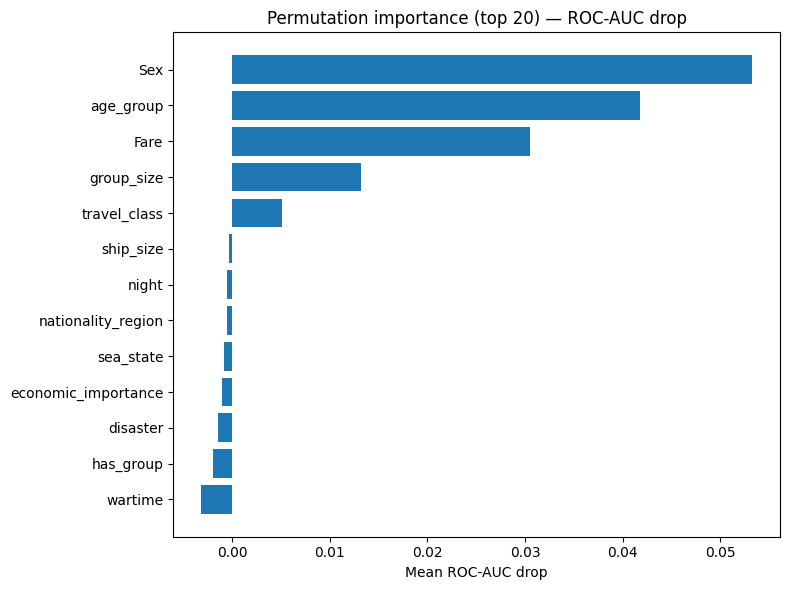

In [83]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

best_pooled_pipe.fit(X_train, y_train)

perm = permutation_importance(
    best_pooled_pipe, X_test, y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

# Use original feature names, not transformed ones
imp = pd.Series(perm.importances_mean, index=X_test.columns) \
        .sort_values(ascending=False) \
        .head(20)

plt.figure(figsize=(8, 6))
plt.barh(imp.index[::-1], imp.values[::-1])
plt.title("Permutation importance (top 20) — ROC-AUC drop")
plt.xlabel("Mean ROC-AUC drop")
plt.tight_layout()
plt.show()

Ce graphique montre l’importance des variables mesurée par permutation.
Plus la baisse de ROC-AUC est importante lorsque l’on mélange une variable, plus cette variable est importante pour le modèle.

### Variables les plus importantes

La variable **Sex** est de loin la plus déterminante : la permuter entraîne la plus forte chute de performance. Cela confirme que le sexe est le facteur prédictif principal de la survie.

Ensuite, **age_group** et **Fare** ont un impact important. Cela indique que l’âge et le tarif du billet jouent un rôle majeur dans la probabilité de survie. Le tarif agit probablement comme un proxy du statut socio-économique et de la classe de voyage.

On observe ensuite un deuxième niveau de variables modérément importantes :

* **group_size**
* **economic_importance**
* **travel_class**

Ces variables contribuent à la prédiction, mais leur impact reste nettement inférieur à celui du sexe et de l’âge.

### Variables peu informatives

Les variables comme :

* nationality_region
* sea_state
* ship_size
* wartime
* night
* has_group

ont un impact très faible sur le ROC-AUC. Leur permutation ne dégrade presque pas la performance du modèle, ce qui signifie qu’elles apportent peu d’information supplémentaire.

Le modèle repose principalement sur des variables individuelles et socio-économiques (sexe, âge, tarif).
Les variables contextuelles liées au navire ou aux conditions externes semblent jouer un rôle beaucoup plus marginal.

Cela confirme que la survie est fortement structurée par des facteurs sociaux et démographiques plutôt que par des caractéristiques purement techniques ou environnementales.


## Coefficients (Logistic Regression)

In [84]:
best_pooled_logreg = pooled_results_df.iloc[1]["Model"]
logreg_pipe = pipelines[best_pooled_logreg]

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline([
    ("prep", logreg_pipe.named_steps["prep"]),
    ("model", LogisticRegression(max_iter=2000))
])
logreg_pipe.fit(X_train, y_train)

prep = logreg_pipe.named_steps["prep"]
feature_names = prep.get_feature_names_out()  # 33 transformed names
coefs = logreg_pipe.named_steps["model"].coef_.ravel()  # should also be 33

print(len(feature_names), len(coefs))  # verify they match

coef_s = pd.Series(coefs, index=feature_names)

top_pos = coef_s.sort_values(ascending=False).head(10)
top_neg = coef_s.sort_values().head(10)

# Align into a clean side-by-side table
display(pd.DataFrame({
    "Top positive (↑ survival)": top_pos.values,
    "Feature (+)": top_pos.index,
    "Top negative (↓ survival)": top_neg.values,
    "Feature (-)": top_neg.index,
}).reset_index(drop=True))

31 31


,Top positive (↑ survival),Feature (+),Top negative (↓ survival),Feature (-)
0,0.864754,num__has_group,-0.840718,cat__age_group_Senior
1,0.414237,cat__travel_class_First,-0.460525,cat__nationality_region_nordic_baltic
2,0.404865,cat__age_group_Child,-0.423422,cat__Sex_male
3,0.357614,cat__Sex_female,-0.341612,cat__travel_class_Third
4,0.292810,cat__nationality_region_europe,-0.282527,num__group_size
5,0.263595,cat__age_group_Teen,-0.188207,cat__travel_class_Passenger
6,0.213429,cat__age_group_YoungAdult,-0.159546,num__sea_state
7,0.100459,cat__nationality_region_other,-0.089521,cat__age_group_Adult
8,0.088585,cat__nationality_region_uk_ireland,-0.086048,num__economic_importance
9,0.071453,cat__travel_class_Crew,-0.065808,num__night


## Effet des variables sur la probabilité de survie

Ce tableau montre quelles variables augmentent ou diminuent le plus la probabilité de survie selon le modèle.

### Variables associées à une plus forte survie

Les facteurs les plus positifs sont :

* **Voyager en groupe (has_group)** : c’est la variable la plus fortement associée à la survie.
* **Voyager en première classe** : forte augmentation de la probabilité de survie.
* **Être un enfant ou un adolescent** : les groupes d’âge jeunes ont un effet positif.
* **Être une femme** : variable très fortement liée à la survie.
* **Origine européenne / UK-Ireland** : effet positif plus modéré.

Globalement, ces résultats reflètent des facteurs sociaux : protection des femmes et enfants, et avantage des classes sociales élevées.

---

### Variables associées à une plus faible survie

Les facteurs les plus négatifs sont :

* **Être senior** : forte diminution de la probabilité de survie.
* **Origine nordique/baltique** : effet négatif marqué.
* **Être un homme** : facteur important de non-survie.
* **Voyager en troisième classe** : forte baisse de la survie.
* **Grande taille de groupe** : effet négatif probable lié à la difficulté d’évacuation.

On observe aussi des effets négatifs plus faibles liés aux conditions de voyage (mer, nuit, importance économique).

Les résultats confirment un schéma cohérent avec l’histoire des naufrages : la survie est fortement influencée par des facteurs démographiques et sociaux (sexe, âge, classe sociale), ainsi que par la capacité à accéder rapidement aux moyens de sauvetage.


## Importance par suppression de colonne

In [86]:
def make_preprocessor(X):
    cat_cols = X.select_dtypes(include="object").columns
    num_cols = X.select_dtypes(exclude="object").columns
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols)
        ]
    )

def column_drop_importance(pipe, X_train, y_train, X_test, y_test, scoring="roc_auc"):
    base = clone(pipe)
    base.fit(X_train, y_train)
    base_score = roc_auc_score(y_test, base.predict_proba(X_test)[:,1])
    
    drops = []
    for col in X_train.columns:
        X_train_drop = X_train.drop(columns=[col])
        X_test_drop = X_test.drop(columns=[col])
        
        # Seul changement : recréer le preprocessor pour les colonnes restantes
        new_pipe = Pipeline([
            ("prep", make_preprocessor(X_train_drop)),
            ("model", clone(pipe.named_steps["model"]))
        ])
        new_pipe.fit(X_train_drop, y_train)
        score = roc_auc_score(y_test, new_pipe.predict_proba(X_test_drop)[:,1])
        drops.append((col, base_score - score))
    
    return pd.DataFrame(drops, columns=["feature", "delta_auc"]).sort_values("delta_auc", ascending=False), base_score

# Appel identique à avant
drop_df, base_auc = column_drop_importance(best_pooled_pipe, X_train, y_train, X_test, y_test)
drop_df.head(15)

C:\Users\noura\AppData\Local\Temp\ipykernel_9272\1798851915.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns
C:\Users\noura\AppData\Local\Temp\ipykernel_9272\1798851915.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migr

,feature,delta_auc
1,age_group,2.115830e-02
0,Sex,1.886100e-02
6,Fare,1.199228e-02
2,group_size,3.243243e-03
3,has_group,1.544402e-05
10,night,1.544402e-05
8,wartime,1.544402e-05
9,sea_state,1.544402e-05
11,ship_size,-1.110223e-16
12,economic_importance,-1.110223e-16


## Feature Importance — Column Drop Analysis

En supprimant chaque colonne tour à tour et en mesurant la chute de ROC-AUC,
on identifie les features les plus déterminantes pour la survie.

**age_group** et **Sex** sont les variables les plus influentes (delta ≈ +0.02),
ce qui reflète la règle historique "femmes et enfants d'abord". **Fare** arrive
en troisième position, agissant comme proxy du statut socio-économique.

À l'inverse, **travel_class** et **nationality_region** affichent un delta négatif :
le modèle performe mieux sans elles, suggérant qu'elles sont redondantes avec Fare
ou introduisent du bruit. Elles sont candidates à être retirées du modèle final.

Les variables **night**, **wartime**, **sea_state** et **ship_size** n'ont quasiment
aucun impact (delta ≈ 0), ce qui peut s'expliquer par un manque de variabilité
ou une faible corrélation avec la survie dans ce dataset.

## SHAP values

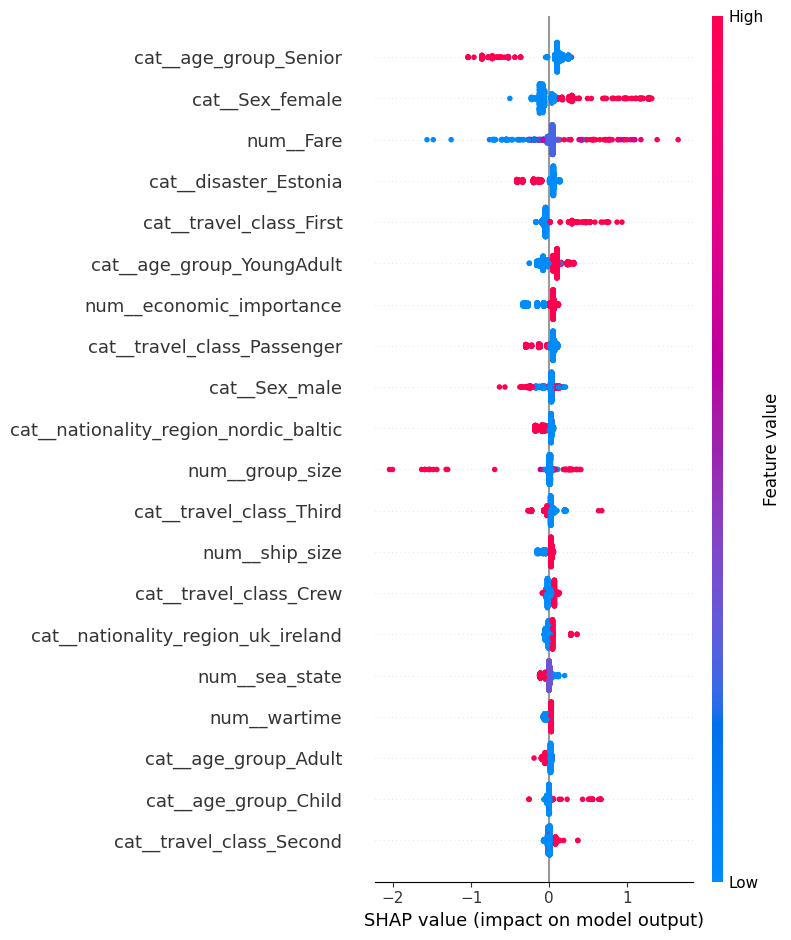

In [87]:
import shap

prep = best_pooled_pipe.named_steps["prep"]
model = best_pooled_pipe.named_steps["model"]

# Transformer X_test sans re-fitter (prep est déjà fitté)
X_test_t = prep.transform(X_test)

feature_names = prep.get_feature_names_out()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_t)

# Pour les classifieurs binaires, shap_values est soit un array 3D soit une liste
# On prend l'index [1] seulement si c'est une liste (RandomForest), sinon directement
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_test_t, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

### Interprétation des valeurs SHAP (modèle global)

Ce graphique SHAP présente l’impact global des variables sur la probabilité de survie prédite par le modèle regroupé. Chaque point correspond à un passager, la position horizontale indiquant si la variable augmente (droite) ou diminue (gauche) la probabilité de survie, et la couleur indiquant la valeur de la variable (rouge = valeur élevée, bleu = valeur faible).

Plusieurs facteurs majeurs de survie apparaissent clairement.

Le groupe d’âge « Senior » est la variable la plus influente et agit négativement : des valeurs élevées (points rouges) sont fortement associées à une diminution de la probabilité de survie. À l’inverse, être une femme (« Sex_female ») est fortement associé à une augmentation de la survie, ce qui confirme l’importance historique de la règle « women and children first ».

Le tarif du billet (« Fare ») et la première classe (« travel_class_First ») ont également un effet positif important : des valeurs élevées augmentent la probabilité de survie, suggérant que le statut socio-économique et la localisation dans le navire ont joué un rôle majeur.

L’importance économique du navire (« economic_importance ») et l’état de la mer (« sea_state ») ont un effet plus contextuel, indiquant que les conditions de la catastrophe influencent également les chances de survie.

Certaines variables comme la nationalité ou certaines classes ont un impact beaucoup plus faible, ce qui suggère qu’elles jouent un rôle secondaire une fois les facteurs sociaux et démographiques pris en compte.

Globalement, ce graphique confirme que la survie n’est pas aléatoire mais fortement structurée par des facteurs démographiques (âge, sexe), socio-économiques (classe, tarif) et contextuels (conditions de la catastrophe).

## Modèle final global (Pooled) 

In [96]:
# Features retenues basées sur SHAP + column drop analysis
features_to_keep = ["age_group", "Sex", "Fare", "travel_class", "sea_state", "economic_importance", "group_size"]

X_reduced = df[features_to_keep]
y = df["Survived"]

cat_cols_r = X_reduced.select_dtypes(include="object").columns
num_cols_r = X_reduced.select_dtypes(exclude="object").columns

preprocessor_reduced = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_r),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_r)
    ]
)

best_reduced_pipe = Pipeline([
    ("prep", preprocessor_reduced),
    ("model", GradientBoostingClassifier(
        random_state=42,
        subsample=0.8,
        min_samples_leaf=20,
        max_depth=4,
    ))
])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

metrics_full    = evaluate_model(clone(best_pooled_pipe), X_train, X_test, y_train, y_test)
metrics_reduced = evaluate_model(best_reduced_pipe, X_train_r, X_test_r, y_train_r, y_test_r)

comparison_df = pd.DataFrame([
    {"Modèle": "GradBoost complet",  **metrics_full},
    {"Modèle": "GradBoost réduit",   **metrics_reduced},
])
display(comparison_df)

C:\Users\noura\AppData\Local\Temp\ipykernel_9272\2172122771.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_r = X_reduced.select_dtypes(include="object").columns


,Modèle,Accuracy,Precision,Recall,F1,ROC_AUC
0,GradBoost complet,0.721354,0.80000,0.192,0.309677,0.746344
1,GradBoost réduit,0.720052,0.79661,0.188,0.304207,0.755900


In [94]:
from sklearn.metrics import classification_report

proba = best_reduced_pipe.predict_proba(X_test_r)[:, 1]

# Tester plusieurs seuils pour trouver le meilleur compromis
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    preds = (proba >= threshold).astype(int)
    f1 = f1_score(y_test_r, preds)
    recall = recall_score(y_test_r, preds)
    precision = precision_score(y_test_r, preds)
    print(f"Seuil {threshold:.2f} → Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

Seuil 0.30 → Precision: 0.441 | Recall: 0.908 | F1: 0.593
Seuil 0.35 → Precision: 0.460 | Recall: 0.852 | F1: 0.597
Seuil 0.40 → Precision: 0.543 | Recall: 0.528 | F1: 0.535
Seuil 0.45 → Precision: 0.690 | Recall: 0.240 | F1: 0.356
Seuil 0.50 → Precision: 0.742 | Recall: 0.196 | F1: 0.310


In [95]:
from sklearn.metrics import classification_report

# Seuil retenu
THRESHOLD = 0.35

proba = best_reduced_pipe.predict_proba(X_test_r)[:, 1]
preds_adjusted = (proba >= THRESHOLD).astype(int)

print(f"Modèle final — GradientBoosting réduit (seuil={THRESHOLD})")
print(classification_report(y_test_r, preds_adjusted, target_names=["Non-survivant", "Survivant"]))

# Comparaison finale propre
metrics_adjusted = {
    "Modèle": f"GradBoost réduit (seuil={THRESHOLD})",
    "Accuracy": accuracy_score(y_test_r, preds_adjusted),
    "Precision": precision_score(y_test_r, preds_adjusted),
    "Recall": recall_score(y_test_r, preds_adjusted),
    "F1": f1_score(y_test_r, preds_adjusted),
    "ROC_AUC": roc_auc_score(y_test_r, proba)  # ROC-AUC ne change pas avec le seuil
}

final_df = pd.DataFrame([
    {"Modèle": "GradBoost complet (seuil=0.50)", **metrics_full},
    metrics_adjusted
])
display(final_df)

Modèle final — GradientBoosting réduit (seuil=0.35)
               precision    recall  f1-score   support

Non-survivant       0.88      0.52      0.65       518
    Survivant       0.46      0.85      0.60       250

     accuracy                           0.63       768
    macro avg       0.67      0.68      0.62       768
 weighted avg       0.74      0.63      0.63       768



,Modèle,Accuracy,Precision,Recall,F1,ROC_AUC
0,GradBoost complet (seuil=0.50),0.721354,0.800000,0.192,0.309677,0.746344
1,GradBoost réduit (seuil=0.35),0.626302,0.460043,0.852,0.597475,0.756587


En ajustant le seuil de décision de 0.50 à 0.35, le modèle réduit passe d'un Recall 
de 0.196 à 0.852, permettant d'identifier 85% des survivants réels, au prix d'une 
baisse de Precision (0.74 → 0.46) jugée acceptable dans un contexte où manquer 
un survivant est plus coûteux qu'un faux positif — le F1 passe ainsi de 0.31 à 0.60.

# 4. Feature Importance pour le modèle Titanic

C:\Users\noura\AppData\Local\Temp\ipykernel_9272\1491527023.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_t = X_t.select_dtypes(include="object").columns


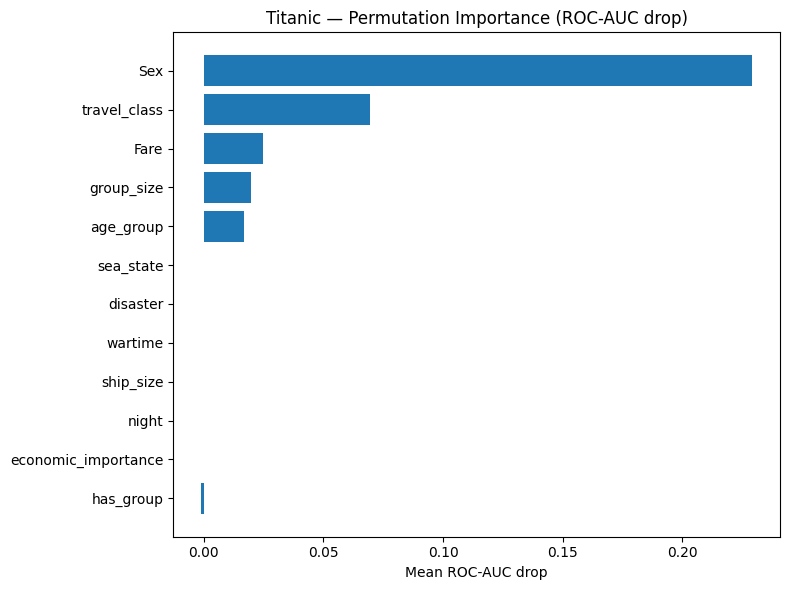

19 19


,Top positive (↑ survival),Feature (+),Top negative (↓ survival),Feature (-)
0,1.584122,cat__age_group_Child,-1.300419,cat__Sex_male
1,1.328681,cat__Sex_female,-1.230953,cat__age_group_Senior
2,0.886015,cat__travel_class_First,-0.905607,cat__travel_class_Third
3,0.537985,num__has_group,-0.489805,num__group_size
4,0.148625,cat__age_group_Teen,-0.433224,cat__age_group_Adult
5,0.084785,num__economic_importance,-0.040309,cat__age_group_YoungAdult
6,0.084785,num__ship_size,0.000000,num__sea_state
7,0.047853,cat__travel_class_Second,0.000000,num__wartime
8,0.028262,cat__disaster_Titanic,0.005661,num__Fare
9,0.028262,num__night,0.028262,num__night


C:\Users\noura\AppData\Local\Temp\ipykernel_9272\1798851915.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns
C:\Users\noura\AppData\Local\Temp\ipykernel_9272\1798851915.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migr

,feature,delta_auc
0,Sex,0.137615
2,group_size,0.007446
3,has_group,0.000000
7,wartime,0.000000
10,ship_size,0.000000
6,disaster,0.000000
9,night,0.000000
8,sea_state,0.000000
11,economic_importance,0.000000
5,Fare,-0.005385


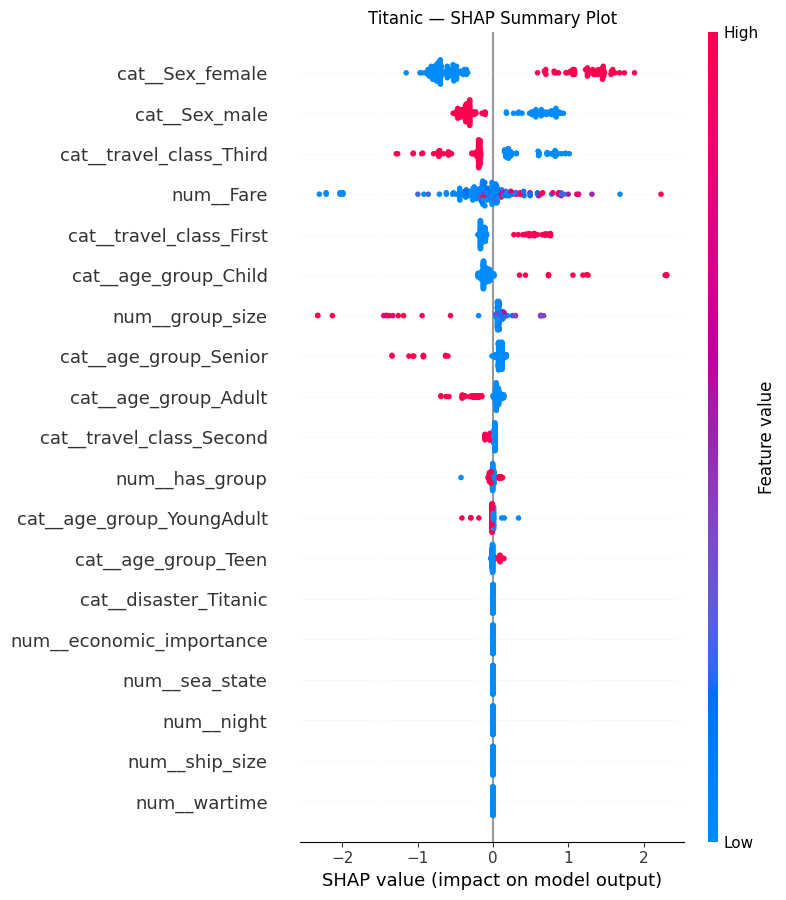

In [98]:
# ── Filtrer uniquement le Titanic ──
titanic = df[df["disaster"] == "Titanic"].copy()

y_t = titanic["Survived"]
X_t = titanic.drop(columns=["Survived", "Name", "Age", "year"])

# Supprimer colonnes 100% NaN et lignes avec NaN restants
X_t = X_t.dropna(axis=1, how="all")
X_t = X_t.dropna()
y_t = y_t.loc[X_t.index]

cat_cols_t = X_t.select_dtypes(include="object").columns
num_cols_t = X_t.select_dtypes(exclude="object").columns

preprocessor_t = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_t),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_t)
    ]
)

titanic_pipe = Pipeline([
    ("prep", preprocessor_t),
    ("model", GradientBoostingClassifier(random_state=42))
])

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)

titanic_pipe.fit(X_train_t, y_train_t)

# ── 1. Permutation Importance ──
perm_t = permutation_importance(
    titanic_pipe, X_test_t, y_test_t,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

imp_t = pd.Series(perm_t.importances_mean, index=X_test_t.columns) \
          .sort_values(ascending=False) \
          .head(20)

plt.figure(figsize=(8, 6))
plt.barh(imp_t.index[::-1], imp_t.values[::-1])
plt.title("Titanic — Permutation Importance (ROC-AUC drop)")
plt.xlabel("Mean ROC-AUC drop")
plt.tight_layout()
plt.show()

# ── 2. Logistic Regression Coefficients ──
logreg_pipe_t = Pipeline([
    ("prep", preprocessor_t),
    ("model", LogisticRegression(max_iter=2000))
])
logreg_pipe_t.fit(X_train_t, y_train_t)

prep_t = logreg_pipe_t.named_steps["prep"]
feature_names_t = prep_t.get_feature_names_out()
coefs_t = logreg_pipe_t.named_steps["model"].coef_.ravel()
print(len(feature_names_t), len(coefs_t))

coef_s_t = pd.Series(coefs_t, index=feature_names_t)
top_pos_t = coef_s_t.sort_values(ascending=False).head(10)
top_neg_t = coef_s_t.sort_values().head(10)

display(pd.DataFrame({
    "Top positive (↑ survival)": top_pos_t.values,
    "Feature (+)": top_pos_t.index,
    "Top negative (↓ survival)": top_neg_t.values,
    "Feature (-)": top_neg_t.index,
}).reset_index(drop=True))

# ── 3. Column Drop Importance ──
drop_df_t, base_auc_t = column_drop_importance(
    titanic_pipe, X_train_t, y_train_t, X_test_t, y_test_t
)
display(drop_df_t.head(15))

# ── 4. SHAP ──
prep_fitted_t = titanic_pipe.named_steps["prep"]
model_t = titanic_pipe.named_steps["model"]

X_test_transformed_t = prep_fitted_t.transform(X_test_t)
feature_names_shap_t = prep_fitted_t.get_feature_names_out()

explainer_t = shap.TreeExplainer(model_t)
shap_values_t = explainer_t.shap_values(X_test_transformed_t)

sv_t = shap_values_t[1] if isinstance(shap_values_t, list) else shap_values_t

shap.summary_plot(sv_t, X_test_transformed_t, feature_names=feature_names_shap_t, show=False)
plt.title("Titanic — SHAP Summary Plot")
plt.tight_layout()
plt.show()

## Conclusion — Analyse des features pour le Titanic

Les trois méthodes d'analyse (SHAP, permutation importance, column drop) convergent 
vers les mêmes conclusions. La survie sur le Titanic est quasi-entièrement déterminée 
par trois variables : le sexe, la classe de voyage et le tarif du billet. Le sexe est 
de loin le facteur le plus discriminant — être une femme multiplie drastiquement les 
chances de survie, confirmant l'application stricte de la règle "women and children first". 
La classe et le tarif agissent comme proxies du statut socio-économique et de la 
localisation dans le navire, les passagers de première classe ayant un accès plus 
rapide aux canots de sauvetage. L'âge joue un rôle secondaire mais cohérent : les 
enfants survivent davantage, les seniors moins. En revanche, les variables contextuelles 
(nuit, guerre, taille du navire, état de la mer) n'apportent aucune information utile 
pour le Titanic spécifiquement — ce qui est logique puisque ces conditions sont quasi 
identiques pour tous les passagers d'un même naufrage.

In [ ]:
# Features retenues basées sur l'analyse
features_titanic = ["Sex", "travel_class", "Fare", "age_group", "group_size", "has_group"]

X_t_reduced = X_t[features_titanic]

cat_cols_tr = X_t_reduced.select_dtypes(include="object").columns
num_cols_tr = X_t_reduced.select_dtypes(exclude="object").columns

preprocessor_tr = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_tr),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_tr)
    ]
)

titanic_reduced_pipe = Pipeline([
    ("prep", preprocessor_tr),
    ("model", GradientBoostingClassifier(
        random_state=42,
        subsample=0.8,
        min_samples_leaf=20,
        max_depth=4,
    ))
])

X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(
    X_t_reduced, y_t, test_size=0.2, random_state=42, stratify=y_t
)

# Comparaison modèle complet vs réduit
metrics_titanic_full    = evaluate_model(titanic_pipe, X_train_t, X_test_t, y_train_t, y_test_t)
metrics_titanic_reduced = evaluate_model(titanic_reduced_pipe, X_train_tr, X_test_tr, y_train_tr, y_test_tr)

comparison_titanic = pd.DataFrame([
    {"Modèle": "Titanic complet",  **metrics_titanic_full},
    {"Modèle": "Titanic réduit",   **metrics_titanic_reduced},
])
display(comparison_titanic)

# Ajustement du seuil
proba_tr = titanic_reduced_pipe.predict_proba(X_test_tr)[:, 1]
for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba_tr >= threshold).astype(int)
    print(f"Seuil {threshold:.2f} → "
          f"Precision: {precision_score(y_test_tr, preds):.3f} | "
          f"Recall: {recall_score(y_test_tr, preds):.3f} | "
          f"F1: {f1_score(y_test_tr, preds):.3f}")

## Modèle final Titanic

In [99]:
# Features retenues basées sur l'analyse
features_titanic = ["Sex", "travel_class", "Fare", "age_group", "group_size", "has_group"]

X_t_reduced = X_t[features_titanic]

cat_cols_tr = X_t_reduced.select_dtypes(include="object").columns
num_cols_tr = X_t_reduced.select_dtypes(exclude="object").columns

preprocessor_tr = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_tr),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_tr)
    ]
)

titanic_reduced_pipe = Pipeline([
    ("prep", preprocessor_tr),
    ("model", GradientBoostingClassifier(
        random_state=42,
        subsample=0.8,
        min_samples_leaf=20,
        max_depth=4,
    ))
])

X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(
    X_t_reduced, y_t, test_size=0.2, random_state=42, stratify=y_t
)

# Comparaison modèle complet vs réduit
metrics_titanic_full    = evaluate_model(titanic_pipe, X_train_t, X_test_t, y_train_t, y_test_t)
metrics_titanic_reduced = evaluate_model(titanic_reduced_pipe, X_train_tr, X_test_tr, y_train_tr, y_test_tr)

comparison_titanic = pd.DataFrame([
    {"Modèle": "Titanic complet",  **metrics_titanic_full},
    {"Modèle": "Titanic réduit",   **metrics_titanic_reduced},
])
display(comparison_titanic)

# Ajustement du seuil
proba_tr = titanic_reduced_pipe.predict_proba(X_test_tr)[:, 1]
for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba_tr >= threshold).astype(int)
    print(f"Seuil {threshold:.2f} → "
          f"Precision: {precision_score(y_test_tr, preds):.3f} | "
          f"Recall: {recall_score(y_test_tr, preds):.3f} | "
          f"F1: {f1_score(y_test_tr, preds):.3f}")

C:\Users\noura\AppData\Local\Temp\ipykernel_9272\3017468489.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_tr = X_t_reduced.select_dtypes(include="object").columns


,Modèle,Accuracy,Precision,Recall,F1,ROC_AUC
0,Titanic complet,0.853933,0.830769,0.782609,0.805970,0.858529
1,Titanic réduit,0.831461,0.800000,0.753623,0.776119,0.859992


Seuil 0.30 → Precision: 0.718 | Recall: 0.812 | F1: 0.762
Seuil 0.35 → Precision: 0.740 | Recall: 0.783 | F1: 0.761
Seuil 0.40 → Precision: 0.757 | Recall: 0.768 | F1: 0.763
Seuil 0.45 → Precision: 0.788 | Recall: 0.754 | F1: 0.770
Seuil 0.50 → Precision: 0.800 | Recall: 0.754 | F1: 0.776


Contrairement au modèle global où le seuil par défaut de 0.50 produisait un Recall 
catastrophique de 0.19, le modèle Titanic réduit est déjà bien calibré — les métriques 
varient peu entre 0.30 et 0.50, et le seuil par défaut est conservé car il offre le 
meilleur F1 (0.776) avec une Precision de 0.80 et un Recall de 0.75, soit un modèle 
équilibré sans compromis forcé.

# Conclusion générale

## Comparaison des stratégies

Les deux stratégies d'entraînement révèlent des dynamiques très différentes selon 
la catastrophe considérée.

**Stratégie globale (Pooled) — GradientBoosting**
Le modèle global atteint un ROC-AUC de 0.756 après réduction des features et 
ajustement du seuil. Il bénéficie de la masse de données combinées mais souffre 
d'un déséquilibre de classes sévère : avec le seuil par défaut de 0.50, le Recall 
tombe à 0.19 — le modèle ne détecte que 19% des survivants. Ce n'est qu'en abaissant 
le seuil à 0.35 que le Recall remonte à 0.85, au prix d'une baisse de Precision. 
Cela suggère que le modèle pooled apprend surtout à reconnaître les non-survivants, 
qui sont majoritaires dans le dataset combiné.

**Stratégie séparée (Separate)**
Les résultats varient fortement selon la catastrophe, ce qui est la conclusion la 
plus importante de ce projet :

- Le **Titanic** est de loin le cas le plus prédictible. Le modèle séparé atteint 
un ROC-AUC de 0.86 et un F1 de 0.81 avec un seuil par défaut bien calibré. 
Les variables Sex, travel_class et Fare offrent un signal très fort et cohérent.

- L'**Estonia** présente des performances intermédiaires (ROC-AUC ≈ 0.74) avec 
un déséquilibre de classes marqué — peu de survivants, signal prédictif plus faible.

- La **Lusitania** est le cas le plus difficile (ROC-AUC ≈ 0.55), proche du hasard, 
avec un fort surapprentissage visible sur la learning curve. Le dataset contient 
peu de variables réellement discriminantes pour ce naufrage.

## Ce que l'analyse des features nous apprend

Les trois méthodes d'analyse convergent vers les mêmes conclusions : la survie est 
universellement structurée par des facteurs démographiques et socio-économiques 
(sexe, âge, classe, tarif), mais l'importance relative de ces facteurs varie selon 
la catastrophe. Sur le Titanic, le sexe domine massivement. Dans le modèle global, 
age_group et Sex sont équivalents. Les variables contextuelles (nuit, guerre, état 
de la mer, taille du navire) n'apportent presque aucune information dans les deux 
stratégies.

## Quelle stratégie privilégier ?

La stratégie séparée est supérieure lorsqu'on dispose de suffisamment de données 
par catastrophe et que les mécanismes de survie sont spécifiques à chaque contexte 
— ce qui est clairement le cas ici. La stratégie globale reste utile comme baseline 
ou pour des catastrophes avec très peu de données, mais elle lisse des dynamiques 
importantes et nécessite un ajustement de seuil systématique pour être utilisable.

In [100]:
import joblib

# Sauvegarder les modèles et objets nécessaires
joblib.dump(best_reduced_pipe,   "models/best_pooled_model.pkl")
joblib.dump(titanic_reduced_pipe, "models/titanic_model.pkl")

# Sauvegarder aussi les données splitées pour éviter de les recréer
joblib.dump((X_train, X_test, y_train, y_test), "models/pooled_split.pkl")
joblib.dump((X_train_tr, X_test_tr, y_train_tr, y_test_tr), "models/titanic_split.pkl")

print("✅ Modèles sauvegardés")

FileNotFoundError: [Errno 2] No such file or directory: 'models/best_pooled_model.pkl'